# Encoder-only transformer model

https://colab.research.google.com/drive/1Uc0PCuSgqSv32NpDukMLQFacL3UGzlOT?usp=sharing

I tried bert base uncased, and Roberta. Roberta performed better. In the end two models were trained, one for 3 epochs and on original downsampled dataset, and the other on for 10 epochs (planned, but due to lack of compute, ended the training early after 6 epochs) on augmented downsampled dataset. The second model performed better, both models are available in my hugging face repositories

## Data loading and inspection

In [ ]:
import pandas as pd
from data.data_loader import DataLoader

data_loader = DataLoader("data/raw/finefoods.txt")
data = data_loader.load()
data.score = data.score.astype(float)

Parsing line: 5116093it [00:03, 1543143.53it/s]


<Axes: title={'center': 'Label distribution'}, xlabel='score'>

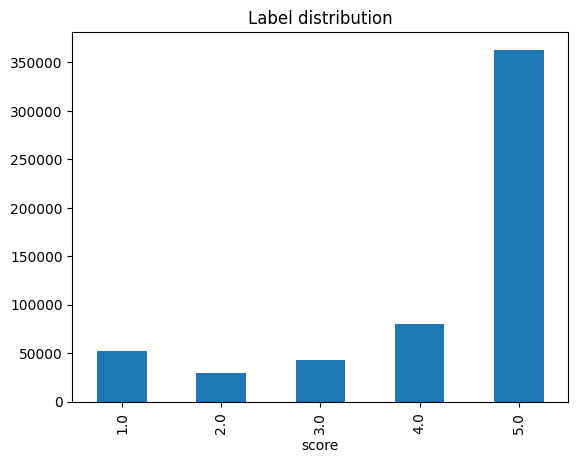

In [ ]:
import matplotlib.pyplot as plt

data.score.value_counts().sort_index().plot(
    kind="bar", title="Label distribution"
)

In [ ]:
augmented_data = pd.read_csv(
    "aff_summary_text_q75_augmented_merged.csv",
    dtype=str
)
augmented_data.score = augmented_data.score.astype(float)
augmented_data.text = augmented_data.text.astype(str) # due to failed augmentation
augmented_data.summary = augmented_data.summary.astype(str) # due to failed augmentation

In [ ]:
augmented_data.head() # check of data load

,productId,userId,profileName,helpfulness,score,time,summary,text,source,augmentation_used_text,augmentation_used_summary
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1/1,5.0,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,original,NaN,NaN
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0/0,1.0,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,original,NaN,NaN
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1/1,4.0,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,original,NaN,NaN
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3/3,2.0,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,original,NaN,NaN
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0/0,5.0,1350777600,Great taffy,Great taffy at a great price. There was a wid...,original,NaN,NaN


<Axes: title={'center': 'Label distribution'}, xlabel='score'>

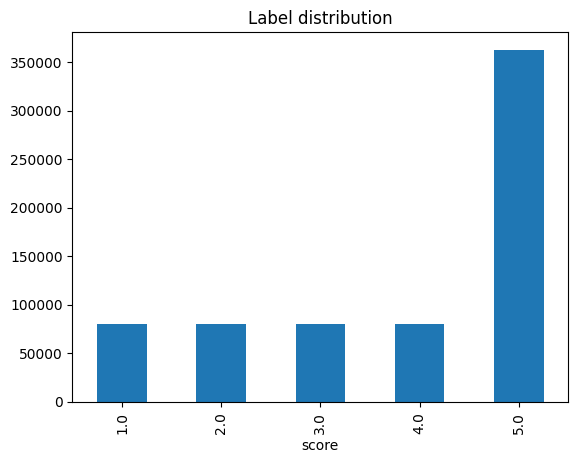

In [ ]:
augmented_data.score.value_counts().sort_index().plot(
    kind="bar", title="Label distribution"
)

In [ ]:
augmented_data.score.value_counts()

,count
score,
5.0,362936
2.0,80651
3.0,80629
4.0,80627
1.0,80618


In [ ]:
from sklearn.utils import resample

def downsample(data, seed=42):
  min_class_size = data['score'].value_counts().min()

  dfs = []
  for label in data['score'].unique():
      class_subset = data[data['score'] == label]
      downsampled = resample(
          class_subset,
          replace=False,
          n_samples=min_class_size,
          random_state=seed
      )
      dfs.append(downsampled)

  return pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

downsampled_augmented_data = downsample(augmented_data)

In [ ]:
downsampled_augmented_data.score.value_counts()

,count
score,
2.0,80618
3.0,80618
4.0,80618
1.0,80618
5.0,80618


Much more equally distributed. But still it is not fair, as 5 is the most frequent score. However, undersampling can be done very easily. I use downsampling because of lack of computational resources, e. g. to make the train dataset smaller

## Data preparation

I do not use cross validation due to computational resources and more balanced dataset. I split data in 80-20 fashion, where the 80 is then again split in 80-20 fashion resulting with train, test and validation data sets.

In [ ]:
from sklearn.model_selection import train_test_split

def build_train_test_val_sets(data: pd.DataFrame, test_size=0.2, val_size=0.2, seed=42, stratify=True):
  X = (data['summary'] + " " + data['text']).to_list()
  y = (data['score'].astype(int) - 1).to_list()
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=seed,
      stratify=y if stratify else None
  )
  X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=val_size, random_state=seed,
    stratify=y_train if stratify else None
  )
  return (X_train, y_train), (X_test, y_test), (X_val, y_val)

(X_train, y_train), (X_test, y_test), (X_val, y_val) = build_train_test_val_sets(downsampled_augmented_data)

In [ ]:
import torch
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len=512):
    self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
    self.labels = list(labels)

  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)


I view the task as classification, even though the advised metrics is RMSE which is more suitable for regression tasks. Regression is also possible, as it also incorporates cardinality of differences between labels (1 and 2, are not different in the same way as 1 and 5, as it would be the case for classification)

In [ ]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=5
).to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)
val_dataset = SentimentDataset(X_val, y_val, tokenizer)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, root_mean_squared_error

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    f1_macro = f1_score(labels, preds, average="macro")
    rmse = root_mean_squared_error(labels, preds)
    return {
        "f1_macro": f1_macro,
        "rmse": rmse #advised in task assignment
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results/roberta",
    overwrite_output_dir=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    fp16=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    num_train_epochs=10,
    warmup_steps=500,
    logging_dir="./logs",
    logging_strategy="steps",
    logging_steps=1_000,
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Rmse
1,0.696500,0.651750,0.728245,0.620127
2,0.584300,0.674890,0.723144,0.640325
3,0.482800,0.622728,0.757218,0.600307
4,0.387000,0.617573,0.782255,0.567213
5,0.316500,0.620057,0.792497,0.554510
6,0.255300,0.640630,0.804560,0.539688


KeyboardInterrupt: 

## Evaluation
I evaluate the model just as I did with the simple ML models using confusion matrix, and f1 score, and RMSE.

In [ ]:
predictions = trainer.predict(test_dataset)

Epoch,Training Loss,Validation Loss,F1 Macro,Rmse
1,0.696500,0.651750,0.728245,0.620127
2,0.584300,0.674890,0.723144,0.640325
3,0.482800,0.622728,0.757218,0.600307
4,0.387000,0.617573,0.782255,0.567213
5,0.316500,0.620057,0.792497,0.554510
6,0.255300,0.640630,0.804560,0.539688


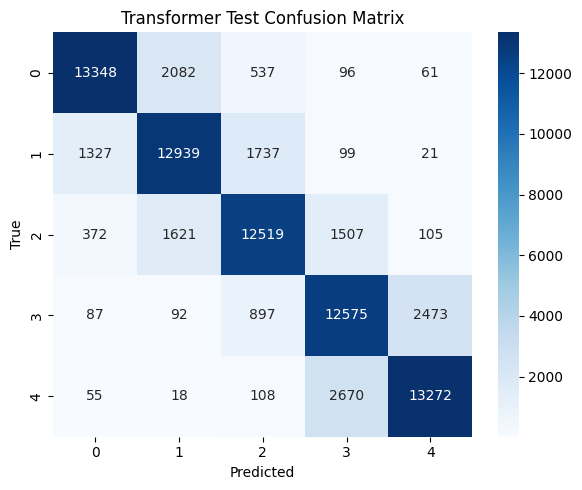

In [ ]:
from utils.evaluation import evaluate_model, plot_confusion_matrix
from utils.io_utils import save_metrics, save_reports
test_metrics = {
    "acc": [],
    "RMSE": [],
    "f1_macro": [],
    "f1_micro": []
}

test_report = []
test_metrics_path = "metrics/test/roberta_10e_augmenteddata_undersampled.csv"
test_report_path = "reports/test/roberta_10e_augmenteddata_undersampled.json"
y_pred = predictions.predictions.argmax(axis=1)
evaluate_model(y_test, y_pred, metrics=test_metrics, reports=test_report)

save_metrics(test_metrics, test_metrics_path)
save_reports(test_report, test_report_path)
plot_confusion_matrix(y_test, y_pred, title="Transformer Test Confusion Matrix")

In [ ]:
test_metrics

{'acc': [0.8019673025875115],
 'RMSE': [0.5389859389332058],
 'f1_macro': [0.8025255724936352],
 'f1_micro': [0.8019673025875115]}

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85     16124
           1       0.77      0.80      0.79     16123
           2       0.79      0.78      0.78     16124
           3       0.74      0.78      0.76     16124
           4       0.83      0.82      0.83     16123

    accuracy                           0.80     80618
   macro avg       0.80      0.80      0.80     80618
weighted avg       0.80      0.80      0.80     80618



As we can see this model has the best results over all classes, and seems to judge them all fairly (similar precision, recall values), this is the best model, and I suspect it would get only better with more training, and potentially with bigger data augmentation.

## Interpretability
Transformers are in contrast to classical ML methods notoriously more obsucre, and are less easy to interpret. There are however some methods and python libraries for interpretabilty. Other than that only optometric evaluation is possible (looking at examples and their assigned labels, and guessing what went wrong).

In [ ]:
import random

model.eval()
idx = random.sample(range(len(X_test)), 10)
review_examples = [X_test[i] for i in idx]
review_sentiments = [y_test[i] for i in idx]
tokenized = tokenizer(review_examples, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = model(**tokenized)
    preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()

for i, (review, true_label, pred_label) in enumerate(zip(review_examples, review_sentiments, preds)):
    print("REVIEW TEXT:")
    print(review)
    print(f"REAL SENTIMENT SCORE: {true_label + 1}")
    print(f"PREDICTED SENTIMENT SCORE: {pred_label + 1}")
    print("-------------------------------------------")

REVIEW TEXT:
Harsh flavor, and yet withal not strong coffee by my criterion I went out on a limb and purchased this 50 pack of Jet Fuel because of so many good reviews. Let me start by saying, I like STRONG coffee. Espresso is fine with me, and when I make my own coffee I make it as strong as can make up. If all I have is instant I at least quadruple the amount of coffee to water. In other words, I like a strong coffee, and Jet Fuel by my standards is strong in flavor only. Okay strong isn ' t the best word; HARSH would be a better word. It ' s not a pleasurable drinking experience. <br /> <br /> I took some to work to let a coworker try it, and I call back he nail the aroma and flavor of this Jet Fuel coffee. He allege it ' s like a dirty ashtray. After he said that it clicked in my mind. Dang, yes that is what it tastes like. Now, I will give the benefit of the doubt that I got a bad batch, but so far since I was a sucker and bought 50 of them, I keep drinking them usually adding ins

In [ ]:
results_df = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": predictions.predictions.argmax(axis=1)
})
results_df["abs_diff"] = (results_df["true"] - results_df["pred"]).abs()

worst = results_df.sort_values("abs_diff", ascending=False).head(10)

for _, row in worst.iterrows():
    print(f"\nTRUE: {row.true + 1}, PRED: {row.pred + 1}, DIFF: {row.abs_diff}")
    print(row.text)
    print("-------------------------------------------")


TRUE: 1, PRED: 5, DIFF: 4
thanks for your review I was about to order this product until I read the reviews, which reflect my sentiment EXACTLY! I called the 800 number on the side of the can. The lady who answered was very kind and sent me a coupon for some cheese. But she didn't seem to think they would ever  necessarily change the formula back. (Groan) I miss my coffee!
-------------------------------------------

TRUE: 5, PRED: 1, DIFF: 4
Product No Longer Available This product, as originally produced, was an excellent addition to fried chicken. I was advised today by McCormick that this product is no longer available. It has been replaced by McCormick's Perfect Pinch Original Chicken seasoning. The new perfect pinch recipe is different from the old. I liked the original but I don't like the new version.
-------------------------------------------

TRUE: 1, PRED: 5, DIFF: 4
Cute If you are like me and just like the cauldron you can pick it up at Walgreens for just a little above 

In [ ]:
import shap

def predict(x):
    tokens = tokenizer(list(x), return_tensors="pt", padding=True, truncation=True).to(model.device)
    output = model(**tokens).logits
    return output.detach().cpu().numpy()

explainer = shap.Explainer(predict, tokenizer)
shap_values = explainer(random.sample(X_test, 10))

shap.plots.text(shap_values[0])

PartitionExplainer explainer: 11it [00:22,  3.24s/it]


We can see that words that hint at good review tend to pull the prediction towards higher scores which is wanted and understandable.

## Saving model to repository

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
model_name = "roberta-base"
model.save_pretrained(model_name)
tokenizer.save_pretrained(model_name)

('roberta-base/tokenizer_config.json',
 'roberta-base/special_tokens_map.json',
 'roberta-base/vocab.json',
 'roberta-base/merges.txt',
 'roberta-base/added_tokens.json',
 'roberta-base/tokenizer.json')

In [ ]:
model.push_to_hub("maennyn/roberta-amazon-finefood-sentiment6e")
tokenizer.push_to_hub("maennyn/roberta-amazon-finefood-sentiment6e")

## Saving augmented dataset to repository

In [ ]:
from datasets import Dataset
dataset = Dataset.from_pandas(augmented_data)

In [ ]:
from huggingface_hub import create_repo, DatasetCard
dataset.push_to_hub("maennyn/amazon_fine_foods_augmented_q75")